# Training — Dataset 2 (classifier head di atas YAMNet)

Melatih **MLP kecil** di atas embedding YAMNet 1024-d yang sudah di-cache
(`ml/cache/yamnet_d2.npz`). YAMNet tidak disentuh — bobotnya beku, kita hanya
melatih classifier head. Ringan, cukup CPU.

**Metrik utama: macro-F1** pada test set (target >85%), bukan accuracy — supaya kelas
yang lebih kecil tetap dihitung setara.

## Alur

1. Muat embedding dari cache, cocokkan dengan split lewat `filename`
2. Standardisasi memakai statistik **train saja** (anti-leakage)
3. Latih MLP, early stopping pada val loss (restore best weights)
4. Evaluasi di test: macro-F1, per-class F1, confusion matrix
5. Simpan artefak + satu baris ke `ml/experiments.csv`

In [1]:
import json
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

# --- reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

# ------------------------------------------------------------------ config
DATASET = "d2"
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ML_DIR = ROOT / "ml"
CACHE = ML_DIR / "cache" / f"yamnet_{DATASET}.npz"
FIG_DIR = ROOT / "figures" / f"train_{DATASET}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXP_ID = f"{DATASET}_yamnet_mlp"
ART_DIR = ML_DIR / "artifacts" / EXP_ID
ART_DIR.mkdir(parents=True, exist_ok=True)

assert CACHE.exists(), f"cache belum ada — jalankan 04_features_yamnet.ipynb dulu: {CACHE}"
print(f"dataset  : {DATASET}")
print(f"cache    : {CACHE}")
print(f"artifacts: {ART_DIR}")

dataset  : d2
cache    : D:\Coding Vscode\Siren Classification\ml\cache\yamnet_d2.npz
artifacts: D:\Coding Vscode\Siren Classification\ml\artifacts\d2_yamnet_mlp


---
## 1 · Rakit data dari cache + split

Embedding di cache diberi indeks `filename`. Tiap split CSV menyebut file mana masuk
mana — kita join keduanya supaya urutan X (embedding) dan y (label) sinkron per split.
Label kelas diturunkan otomatis dari data (D1 3 kelas, D2 4 kelas) lalu di-encode ke
integer terurut alfabet.

In [2]:
data = np.load(CACHE, allow_pickle=True)
emb_by_file = {fn: emb for fn, emb in zip(data["filename"], data["emb"])}

CLASSES = sorted(set(data["label"]))
cls_to_idx = {c: i for i, c in enumerate(CLASSES)}
print(f"kelas ({len(CLASSES)}): {CLASSES}")


def load_split(split: str):
    """Kembalikan (X, y, filenames) untuk satu split, urut sesuai CSV."""
    df = pd.read_csv(ML_DIR / f"split_{DATASET}_{split}.csv")
    X = np.stack([emb_by_file[fn] for fn in df.filename]).astype(np.float32)
    y = df.label.map(cls_to_idx).to_numpy()
    return X, y, df.filename.to_numpy()


X_train, y_train, _ = load_split("train")
X_val,   y_val,   _ = load_split("val")
X_test,  y_test,  f_test = load_split("test")

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    dist = {CLASSES[i]: int((y == i).sum()) for i in range(len(CLASSES))}
    print(f"{name:5s}: {len(y):>4} sampel  {dist}")

kelas (4): ['ambulance', 'firetruck', 'police', 'traffic']
train: 1195 sampel  {'ambulance': 286, 'firetruck': 284, 'police': 324, 'traffic': 301}
val  :  240 sampel  {'ambulance': 56, 'firetruck': 60, 'police': 64, 'traffic': 60}
test :  240 sampel  {'ambulance': 58, 'firetruck': 56, 'police': 66, 'traffic': 60}


---
## 2 · Standardisasi (statistik train saja)

Mean & std dihitung **hanya dari train**, lalu diterapkan ke val dan test. Menghitungnya
dari seluruh data adalah kebocoran halus — test set tidak boleh ikut memengaruhi
penskalaan (lihat CLAUDE.md).

In [3]:
mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True)

# Kolom near-konstan di train (std~0) TIDAK diamplifikasi — kalau tetap dibagi std
# mungil, nilai kecil di val/test membengkak jadi ekstrem dan bikin model overconfident
# (val_loss meledak). Ini perilaku yang sama dengan sklearn StandardScaler.
n_const = int((std < 1e-6).sum())
std = np.where(std < 1e-6, 1.0, std)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

col_mean_max = np.abs(X_train.mean(axis=0)).max()
assert col_mean_max < 1e-3, f"kolom belum ter-pusat: {col_mean_max:.2e}"
print(f"standardisasi ok — max |mean kolom| = {col_mean_max:.1e}, "
      f"kolom near-konstan (tak diskalakan): {n_const}/{X_train.shape[1]}")

standardisasi ok — max |mean kolom| = 2.3e-06, kolom near-konstan (tak diskalakan): 343/1024


---
## 3 · Model — MLP kecil

Classifier head di atas embedding: dua hidden layer dengan dropout, lalu softmax.
Cukup ekspresif untuk memisahkan kelas, tetap ringan supaya tidak overfit di data kecil.

In [4]:
def build_head(input_dim: int, n_classes: int) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ], name=f"{DATASET}_yamnet_head")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_head(X_train.shape[1], len(CLASSES))
model.summary()

Model: "d2_yamnet_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,812 (1.13 MB)

 Trainable params: 295,812 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=32,
    callbacks=callbacks, verbose=2,
)
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nepoch terbaik (val_loss minimum): {best_epoch} dari {len(history.history['loss'])}")

Epoch 1/200


38/38 - 1s - 27ms/step - accuracy: 0.6477 - loss: 0.8961 - val_accuracy: 0.6833 - val_loss: 0.7437 - learning_rate: 0.0010


Epoch 2/200


38/38 - 0s - 4ms/step - accuracy: 0.8301 - loss: 0.4883 - val_accuracy: 0.7125 - val_loss: 0.7480 - learning_rate: 0.0010


Epoch 3/200


...

Epoch 15/200


38/38 - 0s - 4ms/step - accuracy: 0.9916 - loss: 0.0477 - val_accuracy: 0.7625 - val_loss: 1.1661 - learning_rate: 2.5000e-04


Epoch 16/200


38/38 - 0s - 4ms/step - accuracy: 0.9900 - loss: 0.0437 - val_accuracy: 0.7583 - val_loss: 1.2056 - learning_rate: 2.5000e-04



epoch terbaik (val_loss minimum): 1 dari 16


---
## 4 · Evaluasi di test

Angka final. Test set dibuka **sekali** di sini. Macro-F1 adalah metrik utama;
confusion matrix menunjukkan kelas mana yang tertukar (dugaan dari EDA: ambulance /
firetruck / police bisa saling tertukar, traffic paling mudah).

In [6]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

macro_f1 = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)
print(f"TEST macro-F1 : {macro_f1:.4f}   (target > 0.85)")
print(f"TEST accuracy : {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

TEST macro-F1 : 0.7639   (target > 0.85)
TEST accuracy : 0.7667

              precision    recall  f1-score   support

   ambulance      0.756     0.586     0.660        58
   firetruck      0.613     0.821     0.702        56
      police      0.776     0.682     0.726        66
     traffic      0.952     0.983     0.967        60

    accuracy                          0.767       240
   macro avg      0.774     0.768     0.764       240
weighted avg      0.777     0.767     0.765       240



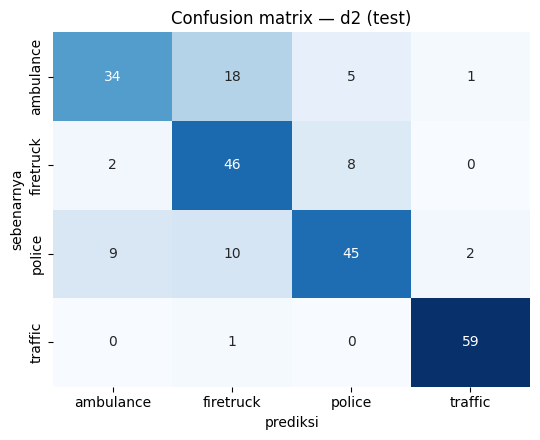

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.xlabel("prediksi"); plt.ylabel("sebenarnya")
plt.title(f"Confusion matrix — {DATASET} (test)")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

---
## 5 · Simpan artefak + catat eksperimen

Tiap eksperimen menyisakan jejak yang bisa direproduksi: model, config, metrics, dan
satu baris di `ml/experiments.csv` (tracking manual, sesuai keputusan di PLANNING).

In [8]:
# --- model + config + metrics ---
model.save(ART_DIR / "model.keras")

config = {
    "exp_id": EXP_ID, "dataset": DATASET, "backbone": "yamnet",
    "head": "mlp_256_128", "features": "yamnet_emb_1024_meanpool",
    "sr": 16000, "duration": 3.0, "seed": SEED,
    "classes": CLASSES, "optimizer": "adam_1e-3", "batch_size": 32,
}
(ART_DIR / "config.json").write_text(json.dumps(config, indent=2))

per_class_f1 = f1_score(y_test, y_pred, average=None).tolist()
metrics = {
    "test_macro_f1": float(macro_f1), "test_accuracy": float(acc),
    "per_class_f1": dict(zip(CLASSES, per_class_f1)),
    "best_epoch": best_epoch, "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
}
(ART_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))

# --- satu baris ke experiments.csv (buat header kalau belum ada) ---
row = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "exp_id": EXP_ID, "dataset": DATASET, "backbone": "yamnet",
    "head": "mlp_256_128", "n_train": len(y_train), "n_test": len(y_test),
    "best_epoch": best_epoch, "test_macro_f1": round(macro_f1, 4),
    "test_accuracy": round(acc, 4),
}
exp_csv = ML_DIR / "experiments.csv"
pd.DataFrame([row]).to_csv(
    exp_csv, mode="a", header=not exp_csv.exists(), index=False)

print(f"artefak  -> {ART_DIR}")
print(f"tercatat -> {exp_csv}")
print(f"\nmacro-F1 {macro_f1:.4f} {'✓ LULUS target' if macro_f1 > 0.85 else '✗ di bawah target 0.85'}")

artefak  -> D:\Coding Vscode\Siren Classification\ml\artifacts\d2_yamnet_mlp
tercatat -> D:\Coding Vscode\Siren Classification\ml\experiments.csv

macro-F1 0.7639 ✗ di bawah target 0.85


---

Baseline selesai. Kalau macro-F1 belum memuaskan, langkah lanjut (satu per satu, catat
tiap perubahan di `experiments.csv`): class weight, tuning arsitektur head, threshold
per-kelas, atau fine-tuning sebagian YAMNet. Untuk perbandingan D1 vs D2, samakan semua
kecuali datasetnya.